# Mrk 421 LHAASO WCDA 周 bin QPO 分析

本 notebook 以 WCDA 周光变为核心，整理出 “光变构建 -> CWT / Lomb–Scargle -> Emmanoulopoulos 零假设 -> GWS 显著性 -> WWZ -> HDF5 模拟样本检查” 的主流程。

原始探索版本已归档至 `archive/notebooks/mkn421_wcda_weekly_raw_20260320.ipynb`。其中并行大规模模拟、2D local significance 与多套 WWZ 显著性试验代码仍完整保留在归档 notebook 中。

In [53]:

from pathlib import Path
import sys

def locate_project_root(*markers):
    candidates = [
        Path.cwd().resolve(),
        Path.cwd().resolve().parent,
        Path('/home/server/projects/QPO'),
        Path('/mnt/mydisk/server/projects/PQO'),
    ]
    for cand in candidates:
        if all((cand / marker).exists() for marker in markers):
            return cand
    raise FileNotFoundError(f'Cannot locate project root for markers: {markers}')

PROJECT_ROOT = locate_project_root('mkn421_lhaaso/LHAASO-WCDA_Mrk421_2021-03-08_2025-11-06_week(1).csv')
WCDA_CSV = PROJECT_ROOT / 'mkn421_lhaaso' / 'LHAASO-WCDA_Mrk421_2021-03-08_2025-11-06_week(1).csv'
SIM_H5 = PROJECT_ROOT / 'mkn421_lhaaso' / 'simulations' / 'wcda_weekly_sims_full.h5'
EMMA_PATH = PROJECT_ROOT / 'mkn421' / 'emmanoulopoulos'
if str(EMMA_PATH) not in sys.path:
    sys.path.insert(0, str(EMMA_PATH))

print('PROJECT_ROOT =', PROJECT_ROOT)
print('WCDA_CSV =', WCDA_CSV)
print('SIM_H5 =', SIM_H5)


PROJECT_ROOT = /mnt/mydisk/server/projects/PQO
WCDA_CSV = /mnt/mydisk/server/projects/PQO/mkn421_lhaaso/LHAASO-WCDA_Mrk421_2021-03-08_2025-11-06_week(1).csv
SIM_H5 = /mnt/mydisk/server/projects/PQO/mkn421_lhaaso/simulations/wcda_weekly_sims_full.h5


## 1. WCDA 周光变构建

由 CSV 中的 `n_on` 与 `n_bkg` 计算 excess rate，作为当前 notebook 的基础时间序列。

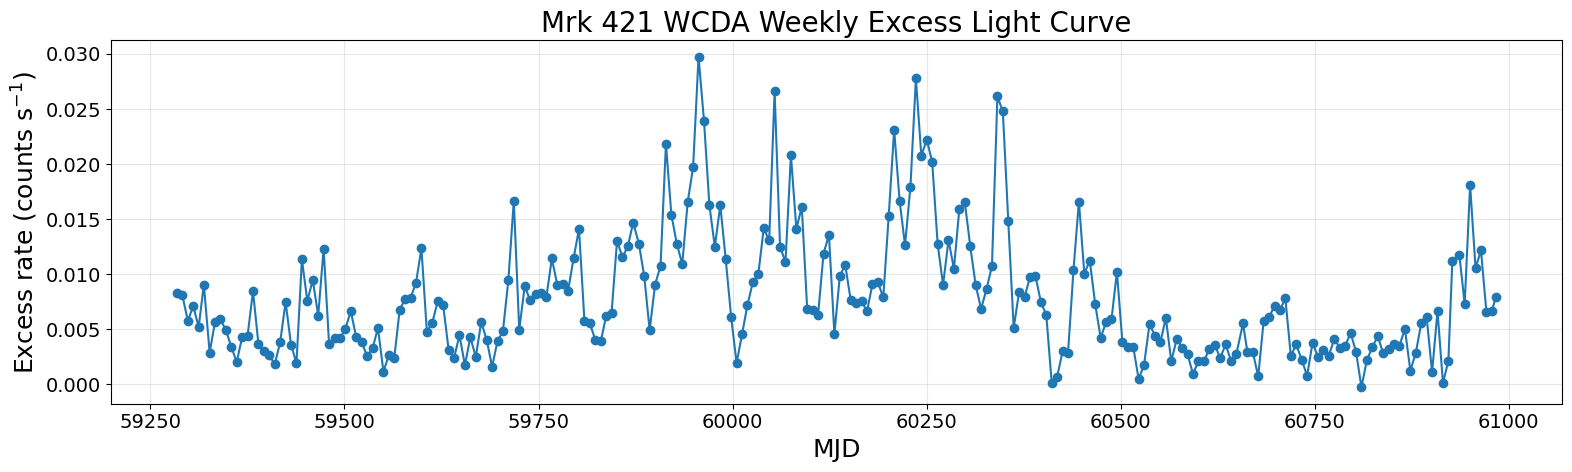

In [54]:
import pandas as pd
import ast
import matplotlib.pyplot as plt

path = str(WCDA_CSV)
df = pd.read_csv(path, comment="#")
df.columns = [c.strip() for c in df.columns]

for col in ["n_on", "n_bkg"]:
    df[col] = df[col].apply(ast.literal_eval)

def excess_rate(row):
    return sum(on - bkg for on, bkg in zip(row["n_on"], row["n_bkg"])) / row["tobs"]

df["flux_excess"] = df.apply(excess_rate, axis=1)
df = df.sort_values("mjd")

# ⭐ 关键：全局字体设置（最重要）
plt.rcParams.update({
    "font.size": 16,        # 基础字体
    "axes.labelsize": 18,   # x/y label
    "axes.titlesize": 20,   # 标题
    "xtick.labelsize": 14,  # x刻度
    "ytick.labelsize": 14,  # y刻度
    "legend.fontsize": 14
})

plt.figure(figsize=(16,5))  # 稍微加高一点
plt.plot(df["mjd"], df["flux_excess"], marker="o", linewidth=1.5)

plt.xlabel("MJD")
plt.ylabel("Excess rate (counts s$^{-1}$)")
plt.title("Mrk 421 WCDA Weekly Excess Light Curve")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [55]:
# 做小波分析
import numpy as np
t_mjd = df["mjd"] 
flux = df["flux_excess"]
# 去掉 NaN 或 TS 很低的点（如果有的话）
mask = np.isfinite(flux)
t_mjd = t_mjd[mask]
flux  = flux[mask]



## 2. CWT 与 Lomb–Scargle 快速检查

CWT 用于观察候选尺度的时间局域性，Lomb–Scargle 作为非等间隔采样下的粗筛参考。其解析 FAP 仅适合作为白噪声基线提示，不能替代红噪声显著性检验。

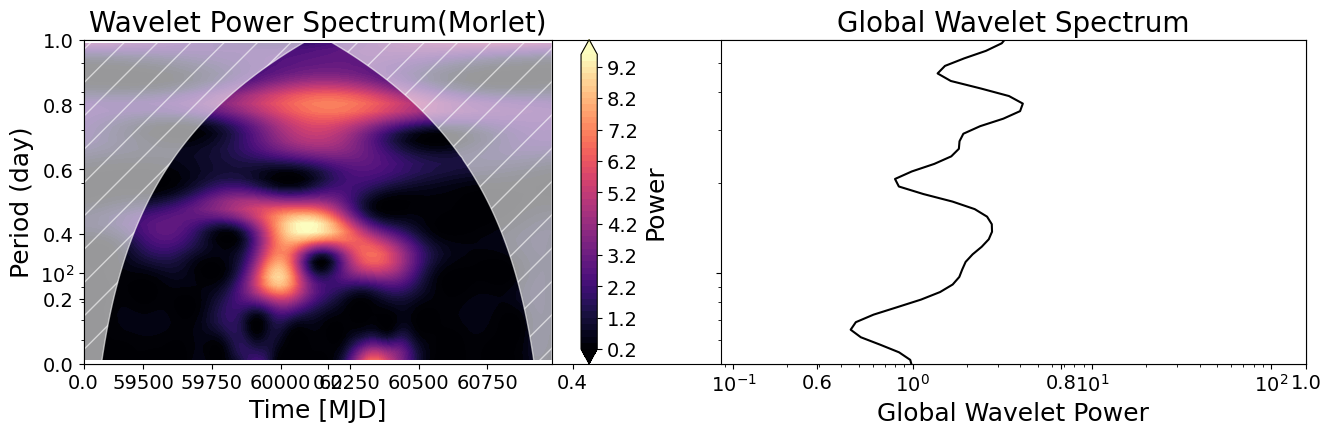

In [56]:
import matplotlib.pyplot as plt
import pycwt as wavelet
import numpy as np

# ==== 数据准备 ====
y = (flux - np.mean(flux)).to_numpy(dtype=float)
y /= np.std(y)

dt = np.median(np.diff(t_mjd))
mother = wavelet.Morlet(6)
dj = 1 / 12
s0 = 2 * dt
J = int(np.log2(len(y) * dt / s0) / dj)

# ==== CWT ====
wave, scales, freqs, coi, fft, fftfreqs = wavelet.cwt(
    y, dt, dj=dj, s0=s0, J=J, wavelet=mother
)

power = np.abs(wave) ** 2
period = 1 / freqs
T, P = np.meshgrid(t_mjd, period)

# 保存一份专用的 CWT 变量，避免后续被 Lomb–Scargle 等单元覆盖。
power_cwt = np.asarray(power, dtype=float)
period_cwt = np.asarray(period, dtype=float)
coi_cwt = np.asarray(coi, dtype=float)
T_cwt = np.asarray(T, dtype=float)
P_cwt = np.asarray(P, dtype=float)

# ------------------------------------------------------------------------------
#                              FIGURE
# ------------------------------------------------------------------------------
fig = plt.subplots(figsize=(14, 5))[0]

ax1 = fig.add_subplot(121)

Pmin = 50
Pmax = 600
maskP = (period_cwt >= Pmin) & (period_cwt <= Pmax)
Pmin_cwt = Pmin
Pmax_cwt = Pmax
maskP_cwt = maskP.copy()

im = ax1.contourf(
    T_cwt[maskP_cwt, :],
    P_cwt[maskP_cwt, :],
    power_cwt[maskP_cwt, :],
    levels=50,
    extend='both',
    cmap='magma'
)

ax1.fill_between(
    t_mjd,
    Pmax_cwt,
    coi_cwt,
    where=(coi_cwt <= Pmax_cwt),
    color='white',
    alpha=0.6,
    hatch='/'
)

ax1.set_yscale('log')
ax1.set_ylabel('Period (day)')
ax1.set_xlabel('Time [MJD]')
ax1.set_title('Wavelet Power Spectrum(Morlet)')
ax1.set_ylim(Pmin_cwt, Pmax_cwt)

cbar = fig.colorbar(im, ax=ax1)
cbar.set_label('Power')

ax2 = fig.add_subplot(122, sharey=ax1)

GWS = np.mean(power_cwt, axis=1)
ax2.plot(GWS, period_cwt, color='black')
ax2.set_xscale('log')
ax2.set_xlabel('Global Wavelet Power')
ax2.set_title('Global Wavelet Spectrum')
plt.setp(ax2.get_yticklabels(), visible=False)

plt.tight_layout()
plt.show()

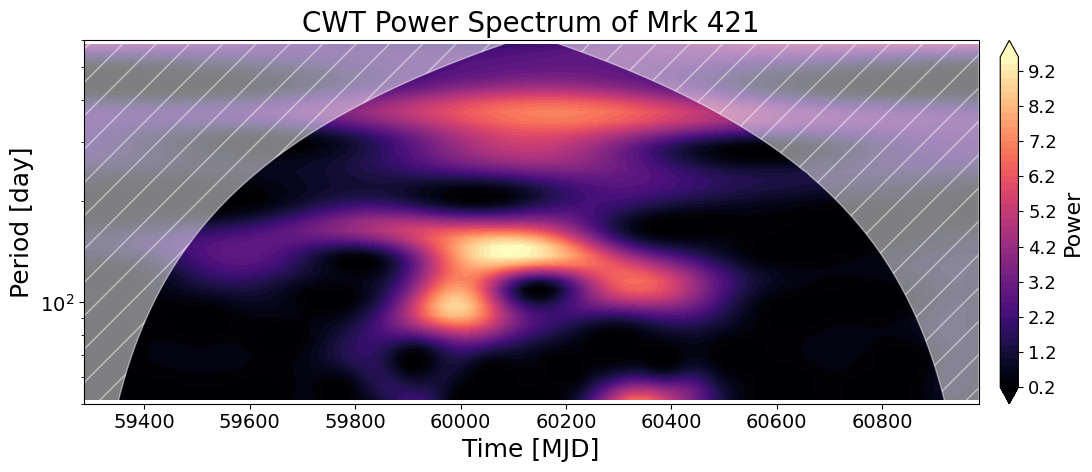

In [57]:
# 生成放入 latex / 汇报图中的单栏 CWT 图。
import matplotlib.pyplot as plt
import pycwt as wavelet
import numpy as np

# ==== 数据准备 ====
y = (flux - np.mean(flux)).to_numpy(dtype=float)
y /= np.std(y)

dt = np.median(np.diff(t_mjd))
mother = wavelet.Morlet(6)
dj = 1 / 12
s0 = 2 * dt
J = int(np.log2(len(y) * dt / s0) / dj)

# ==== CWT ====
wave, scales, freqs, coi, fft, fftfreqs = wavelet.cwt(
    y, dt, dj=dj, s0=s0, J=J, wavelet=mother
)

power = np.abs(wave) ** 2
period = 1 / freqs
T, P = np.meshgrid(t_mjd, period)

# 保存专用变量，供后续二维显著性 contour 直接复用。
power_cwt = np.asarray(power, dtype=float)
period_cwt = np.asarray(period, dtype=float)
coi_cwt = np.asarray(coi, dtype=float)
T_cwt = np.asarray(T, dtype=float)
P_cwt = np.asarray(P, dtype=float)

Pmin = 50
Pmax = 600
maskP = (period_cwt >= Pmin) & (period_cwt <= Pmax)
Pmin_cwt = Pmin
Pmax_cwt = Pmax
maskP_cwt = maskP.copy()

plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 18,
    'axes.titlesize': 20,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

fig, ax = plt.subplots(figsize=(12, 5))

im = ax.contourf(
    T_cwt[maskP_cwt, :],
    P_cwt[maskP_cwt, :],
    power_cwt[maskP_cwt, :],
    levels=50,
    cmap='magma',
    extend='both'
)

ax.fill_between(
    t_mjd,
    Pmax_cwt,
    coi_cwt,
    where=(coi_cwt <= Pmax_cwt),
    color='white',
    alpha=0.5,
    hatch='/'
)

ax.set_yscale('log')
ax.set_ylim(Pmin_cwt, Pmax_cwt)
ax.set_xlabel('Time [MJD]')
ax.set_ylabel('Period [day]')
ax.set_title('CWT Power Spectrum of Mrk 421')

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('Power', fontsize=16)
cbar.ax.tick_params(labelsize=13)

plt.tight_layout()
plt.show()

baseline = 1699.25 d, dt_med = 7.00 d
Search period range: [14.00, 1359.40] days
Best period = 1258.70 days (f = 0.00079447 1/day)
Analytic FAP at best peak = nan


/home/server/anaconda3/envs/fermipy/lib/python3.9/site-packages/astropy/timeseries/periodograms/lombscargle/_statistics.py:140: RuntimeWarning: invalid value encountered in scalar power
  return (1 - z) ** (0.5 * Nk)
/home/server/anaconda3/envs/fermipy/lib/python3.9/site-packages/astropy/timeseries/periodograms/lombscargle/_statistics.py:251: RuntimeWarning: overflow encountered in scalar power
  return _gamma(NH) * W * (1 - Z) ** (0.5 * (NK - 1)) * np.sqrt(0.5 * NH * Z)


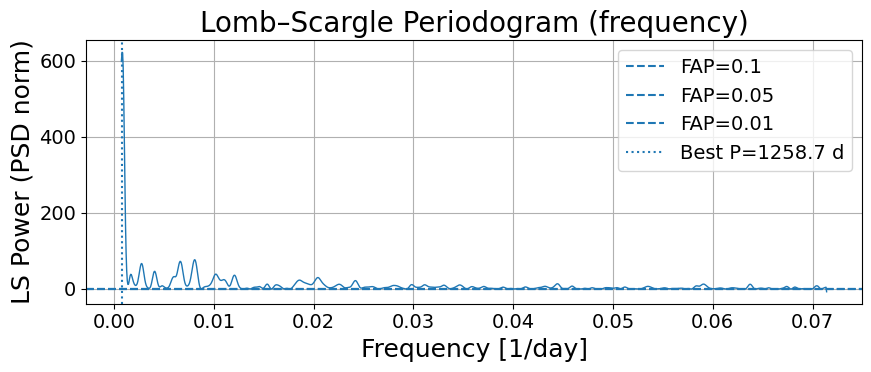

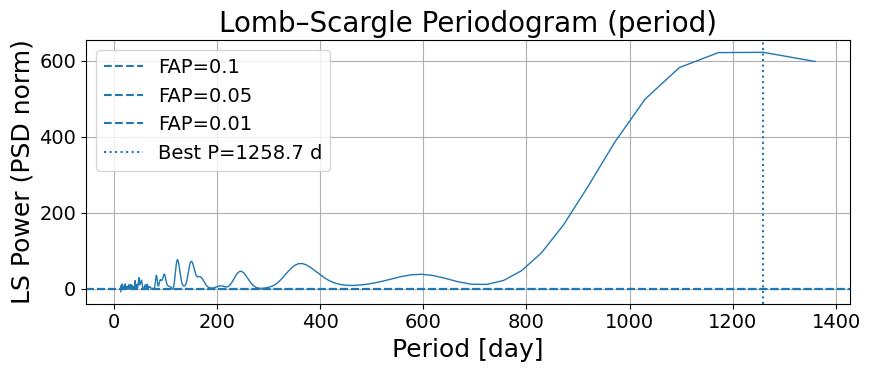

In [58]:
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

# =======================
# 读入数据 + 计算 excess rate
# =======================
path = str(WCDA_CSV)
df = pd.read_csv(path, comment='#')
df.columns = [c.strip() for c in df.columns]

for col in ['n_on', 'n_bkg']:
    df[col] = df[col].apply(ast.literal_eval)

df['excess_counts'] = df.apply(lambda r: sum(on - bkg for on, bkg in zip(r['n_on'], r['n_bkg'])), axis=1)
df['flux_excess'] = df['excess_counts'] / df['tobs']
df['n_on_tot'] = df['n_on'].apply(sum)
df['n_bkg_tot'] = df['n_bkg'].apply(sum)
df['flux_err'] = np.sqrt(df['n_on_tot'] + df['n_bkg_tot']) / df['tobs']

df = df.sort_values('mjd').reset_index(drop=True)

t = df['mjd'].to_numpy()
y = df['flux_excess'].to_numpy()
dy = df['flux_err'].to_numpy()
y0 = y - np.nanmean(y)

baseline = t.max() - t.min()
dt_med = np.median(np.diff(t))

P_min = 2.0 * dt_med
P_max = 0.8 * baseline

f_min = 1.0 / P_max
f_max = 1.0 / P_min
samples_per_peak = 10

ls = LombScargle(t, y0, dy)
frequency, ls_power = ls.autopower(
    minimum_frequency=f_min,
    maximum_frequency=f_max,
    samples_per_peak=samples_per_peak,
    normalization='psd',
)

best_idx = np.argmax(ls_power)
best_f = frequency[best_idx]
best_P = 1.0 / best_f

fap_levels = [0.1, 0.05, 0.01]
power_levels = ls.false_alarm_level(fap_levels)

print(f'baseline = {baseline:.2f} d, dt_med = {dt_med:.2f} d')
print(f'Search period range: [{P_min:.2f}, {P_max:.2f}] days')
print(f'Best period = {best_P:.2f} days (f = {best_f:.5g} 1/day)')
print('Analytic FAP at best peak =', ls.false_alarm_probability(ls_power[best_idx]))

plt.figure(figsize=(9, 4))
plt.plot(frequency, ls_power, lw=1)
for lev, plev in zip(fap_levels, power_levels):
    plt.axhline(plev, ls='--', label=f'FAP={lev}')
plt.axvline(best_f, ls=':', label=f'Best P={best_P:.1f} d')
plt.xlabel('Frequency [1/day]')
plt.ylabel('LS Power (PSD norm)')
plt.title('Lomb–Scargle Periodogram (frequency)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

period_ls = 1.0 / frequency
order = np.argsort(period_ls)

plt.figure(figsize=(9, 4))
plt.plot(period_ls[order], ls_power[order], lw=1)
for lev, plev in zip(fap_levels, power_levels):
    plt.axhline(plev, ls='--', label=f'FAP={lev}')
plt.axvline(best_P, ls=':', label=f'Best P={best_P:.1f} d')
plt.xlabel('Period [day]')
plt.ylabel('LS Power (PSD norm)')
plt.title('Lomb–Scargle Periodogram (period)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. 直接复用已保存的 Emmanoulopoulos 模拟库

当前项目目录中已经存在与 WCDA 观测逐点对应的模拟光变库 `wcda_weekly_sims_full.h5`（10000 条模拟、244 个时间点、全部完成）。因此 notebook 默认**直接加载已保存的 HDF5**，不再现场调用 `Emmanoulopoulos_Sampler` 逐条生成。

如果后续需要重做模拟，请使用 `mkn421_lhaaso/simulations/generate_wcda_weekly_sims.py`，而不是在 notebook 里长时间现算。

In [59]:
import json
import h5py
import numpy as np

SIM_SCRIPT = PROJECT_ROOT / 'mkn421_lhaaso' / 'simulations' / 'generate_wcda_weekly_sims.py'

t_mjd = np.asarray(df['mjd'], dtype=float)
flux = np.asarray(df['flux_excess'], dtype=float)
mask = np.isfinite(t_mjd) & np.isfinite(flux)
t_mjd = t_mjd[mask]
flux = flux[mask]
dt = float(np.median(np.diff(t_mjd)))

with h5py.File(SIM_H5, 'r') as f:
    sim_meta = json.loads(f.attrs['meta_json'])
    t_h5 = f['t_mjd_clean'][:]
    flux_obs_h5 = f['flux_obs_clean'][:]
    Nsim_total, Nt_h5 = f['flux_sims'].shape
    done_count = int(f['done_mask'][:].sum())

if not np.allclose(t_h5, t_mjd):
    raise RuntimeError('Saved t_mjd_clean does not match current WCDA light curve.')
if not np.allclose(flux_obs_h5, flux):
    raise RuntimeError('Saved flux_obs_clean does not match current WCDA light curve.')

print('SIM_H5 =', SIM_H5)
print('Matched observation points =', Nt_h5)
print('Completed simulations =', done_count, '/', Nsim_total)
print('dt_days =', sim_meta.get('dt_days'))
print('Regenerate command example:')
print(f'python {SIM_SCRIPT} --output {SIM_H5}')

SIM_H5 = /mnt/mydisk/server/projects/PQO/mkn421_lhaaso/simulations/wcda_weekly_sims_full.h5
Matched observation points = 244
Completed simulations = 10000 / 10000
dt_days = 6.999996295890014
Regenerate command example:
python /mnt/mydisk/server/projects/PQO/mkn421_lhaaso/simulations/generate_wcda_weekly_sims.py --output /mnt/mydisk/server/projects/PQO/mkn421_lhaaso/simulations/wcda_weekly_sims_full.h5


In [60]:
# 抽样一部分模拟样本，用于 PDF / CDF / PSD 与 GWS 快速检查。
Nsim_check = 200
seed = 42

with h5py.File(SIM_H5, 'r') as f:
    flux_sims_ds = f['flux_sims']
    Nsim_total, Nt = flux_sims_ds.shape

    rng = np.random.default_rng(seed)
    idx = rng.choice(Nsim_total, size=min(Nsim_check, Nsim_total), replace=False)
    idx_sorted = np.sort(idx)
    flux_sims_sub_sorted = flux_sims_ds[idx_sorted, :]
    inv = np.argsort(np.argsort(idx))
    flux_sims_sub = np.asarray(flux_sims_sub_sorted[inv, :], dtype=float)

print('QC subset shape =', flux_sims_sub.shape)

QC subset shape = (200, 244)


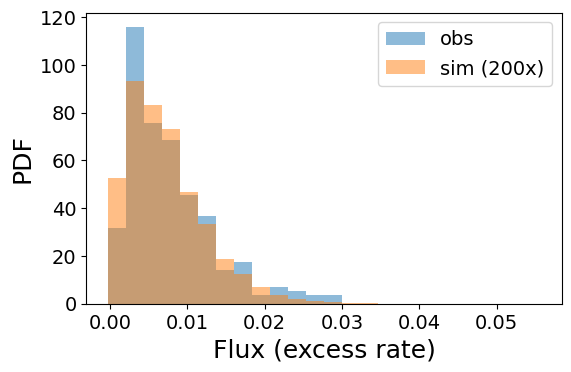

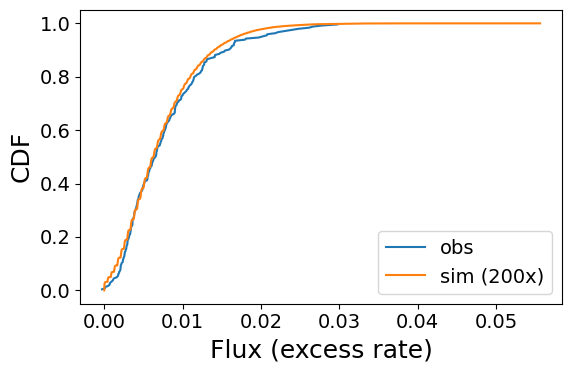

In [61]:
# PDF / CDF 检查：确认保存下来的模拟样本仍与观测分布相容。
flux_obs = flux.copy()
flux_sims_all = flux_sims_sub.reshape(-1)

bins = np.linspace(
    min(np.nanmin(flux_obs), np.nanmin(flux_sims_all)),
    max(np.nanmax(flux_obs), np.nanmax(flux_sims_all)),
    25,
)

plt.figure(figsize=(6, 4))
plt.hist(flux_obs, bins=bins, density=True, alpha=0.5, label='obs')
plt.hist(flux_sims_all, bins=bins, density=True, alpha=0.5, label=f'sim ({len(flux_sims_sub)}x)')
plt.xlabel('Flux (excess rate)')
plt.ylabel('PDF')
plt.legend()
plt.tight_layout()
plt.show()

x_obs = np.sort(flux_obs)
F_obs = np.arange(1, len(x_obs) + 1) / (len(x_obs) + 1)
x_sim = np.sort(flux_sims_all)
F_sim = np.arange(1, len(x_sim) + 1) / (len(x_sim) + 1)

plt.figure(figsize=(6, 4))
plt.plot(x_obs, F_obs, label='obs')
plt.plot(x_sim, F_sim, label=f'sim ({len(flux_sims_sub)}x)')
plt.xlabel('Flux (excess rate)')
plt.ylabel('CDF')
plt.legend()
plt.tight_layout()
plt.show()

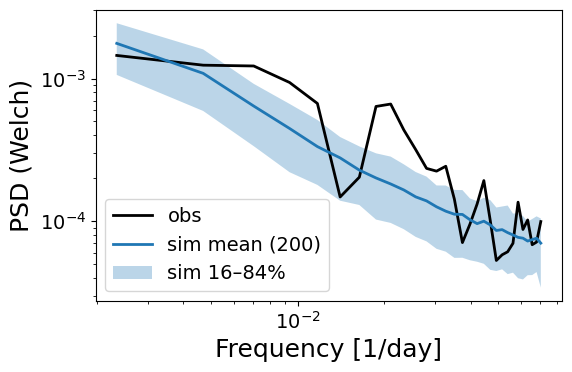

In [62]:
# PSD 检查：这里对保存下来的模拟样本做 Welch PSD，对比观测 PSD。
from scipy.signal import welch

def one_psd(x, fs, nperseg=None):
    x = np.asarray(x, float)
    x = x - np.mean(x)
    if nperseg is None:
        nperseg = max(16, len(x) // 4)
    f, Pxx = welch(
        x,
        fs=fs,
        window='hann',
        nperseg=nperseg,
        noverlap=nperseg // 2,
        detrend='constant',
        scaling='density',
    )
    return f, Pxx

fs = 1.0 / dt
f_obs, P_obs = one_psd(flux_obs, fs=fs)

P_sims = []
for flux_sim in flux_sims_sub:
    f_sim, P_sim = one_psd(flux_sim, fs=fs)
    if not np.allclose(f_sim, f_obs):
        raise RuntimeError('Frequency grid mismatch in Welch PSD.')
    P_sims.append(P_sim)

P_sims = np.vstack(P_sims)
P_mean = P_sims.mean(axis=0)
P16 = np.percentile(P_sims, 16, axis=0)
P84 = np.percentile(P_sims, 84, axis=0)

m = f_obs > 0
plt.figure(figsize=(6, 4))
plt.loglog(f_obs[m], P_obs[m], 'k', lw=2, label='obs')
plt.loglog(f_obs[m], P_mean[m], lw=2, label=f'sim mean ({len(flux_sims_sub)})')
plt.fill_between(f_obs[m], P16[m], P84[m], alpha=0.3, label='sim 16–84%')
plt.xlabel('Frequency [1/day]')
plt.ylabel('PSD (Welch)')
plt.legend()
plt.tight_layout()
plt.show()

## 4. GWS pre-trial 显著性框架

这里不再现场生成 5000 条模拟，而是直接从 `wcda_weekly_sims_full.h5` 读取保存好的 `flux_sims`，再计算每条模拟的 GWS。这样耗时主要来自 wavelet 计算，而不再卡在 Emmanoulopoulos 抽样本身。

In [63]:
# 编写 GWS / local CWT power 的辅助函数。
import numpy as np
import pycwt as wavelet


def compute_gws(flux, dt, dj=1/12, s0=None, J=None, mother=None, standardize=True):
    """给定 flux 返回 (period_grid, gws)。"""
    if mother is None:
        mother = wavelet.Morlet(6)
    if s0 is None:
        s0 = 2 * dt
    if J is None:
        J = int(np.log2(len(flux) * dt / s0) / dj)

    y = np.asarray(flux, float)
    if standardize:
        y = y - np.mean(y)
        y = y / np.std(y)

    w, scales, freqs, coi, fft, fftfreqs = wavelet.cwt(
        y, dt, dj=dj, s0=s0, J=J, wavelet=mother
    )
    power = np.abs(w) ** 2
    period_grid = 1.0 / freqs
    gws = np.mean(power, axis=1)
    return period_grid, gws


def compute_local_power(flux, dt, dj, s0, J, mother):
    """给定 flux 返回 (period_grid, local_power, coi)。"""
    y = np.asarray(flux, float)
    y = y - np.mean(y)
    y = y / np.std(y)

    w, scales, freqs, coi, fft, fftfreqs = wavelet.cwt(
        y, dt, dj=dj, s0=s0, J=J, wavelet=mother
    )
    power = np.abs(w) ** 2
    period_grid = 1.0 / freqs
    return period_grid, power, coi

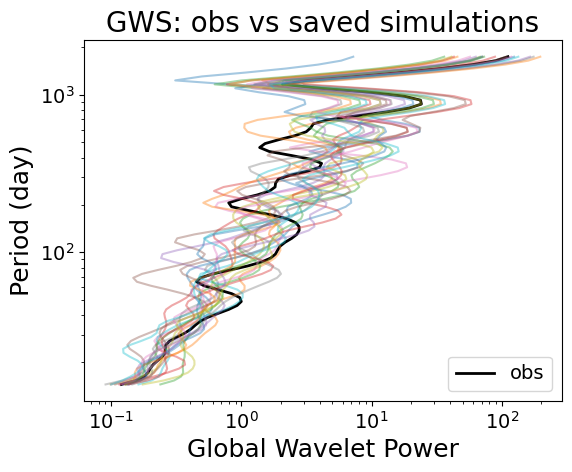

In [64]:
# 计算观测的 GWS，并与一小部分已保存模拟的 GWS 叠加对比。
dt = np.median(np.diff(t_mjd))  # day
mother = wavelet.Morlet(6)
dj = 1/12
s0 = 2 * dt
J = int(np.log2(len(flux) * dt / s0) / dj)
period_obs, gws_obs = compute_gws(flux, dt, dj=dj, s0=s0, J=J, mother=mother, standardize=True)

n_show = min(20, len(flux_sims_sub))
plt.figure(figsize=(6, 5))
plt.plot(gws_obs, period_obs, 'k', lw=2, label='obs')

for i in range(n_show):
    flux_sim = flux_sims_sub[i]
    period_sim, gws_sim = compute_gws(
        flux_sim,
        dt,
        dj=dj,
        s0=s0,
        J=J,
        mother=mother,
        standardize=True,
    )
    if not np.allclose(period_sim, period_obs):
        raise RuntimeError('period grid mismatch: check dt/dj/s0/J consistency')
    plt.plot(gws_sim, period_sim, alpha=0.4)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Global Wavelet Power')
plt.ylabel('Period (day)')
plt.title('GWS: obs vs saved simulations')
plt.legend()
plt.tight_layout()
plt.show()

In [65]:
from tqdm import tqdm
import h5py
import numpy as np

Nsim_use = 5000     # 如需使用全部样本，可改为 10000 或更小的调试值。
read_chunk = 256

with h5py.File(SIM_H5, 'r') as f:
    flux_sims_ds = f['flux_sims']
    Nsim_total = flux_sims_ds.shape[0]
    Nsim_use = min(Nsim_use, Nsim_total)

    GWS_sims = []
    period_ref = None

    for start in tqdm(range(0, Nsim_use, read_chunk)):
        end = min(Nsim_use, start + read_chunk)
        flux_chunk = np.asarray(flux_sims_ds[start:end], dtype=float)

        for flux_sim in flux_chunk:
            period_sim, gws_sim = compute_gws(
                flux_sim,
                dt,
                dj=dj,
                s0=s0,
                J=J,
                mother=mother,
                standardize=True,
            )
            if period_ref is None:
                period_ref = period_sim
            elif not np.allclose(period_sim, period_ref):
                raise RuntimeError('Period grid mismatch')
            GWS_sims.append(gws_sim)

GWS_sims = np.asarray(GWS_sims)
print('Using saved simulations:', GWS_sims.shape)

100%|██████████| 20/20 [00:05<00:00,  3.79it/s]

Using saved simulations: (5000, 84)


In [66]:
# 用 Gamma(≈scaled χ²) 拟合 GWS 的模拟分布，得到 1/3/5σ pre-trial 阈值。
import numpy as np
from scipy.stats import gamma, norm

sigmas = np.array([1, 3, 5], dtype=float)
q = norm.cdf(sigmas)

thr_1s = np.empty(GWS_sims.shape[1])
thr_3s = np.empty(GWS_sims.shape[1])
thr_5s = np.empty(GWS_sims.shape[1])
k_eff = np.empty(GWS_sims.shape[1])

for j in range(GWS_sims.shape[1]):
    x = GWS_sims[:, j]
    x = x[np.isfinite(x)]
    x = x[x > 0]

    try:
        a_hat, _, scale_hat = gamma.fit(x, floc=0)
        if (not np.isfinite(a_hat)) or (not np.isfinite(scale_hat)) or (a_hat <= 0) or (scale_hat <= 0):
            raise ValueError('bad gamma parameters')
    except Exception:
        mu = x.mean()
        sd = x.std(ddof=1)
        a_hat = (mu / sd) ** 2
        scale_hat = (sd ** 2) / mu

    k_eff[j] = 2 * a_hat
    thr_1s[j], thr_3s[j], thr_5s[j] = gamma.ppf(q, a=a_hat, loc=0, scale=scale_hat)

print('median k_eff =', np.median(k_eff))

median k_eff = 8.508207990786346


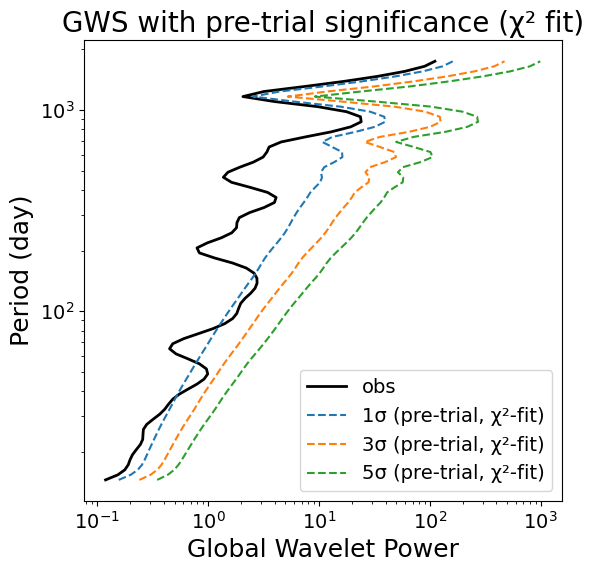

In [67]:
# 画GWS和卡方拟合的置信度分位数
plt.figure(figsize=(6, 6))

plt.plot(gws_obs, period_obs, 'k', lw=2, label="obs")

plt.plot(thr_1s, period_obs, '--', label="1σ (pre-trial, χ²-fit)")
plt.plot(thr_3s, period_obs, '--', label="3σ (pre-trial, χ²-fit)")
plt.plot(thr_5s, period_obs, '--', label="5σ (pre-trial, χ²-fit)")

plt.xscale("log")
plt.yscale("log")
# 你想大周期在上可以取消注释
# plt.gca().invert_yaxis()

plt.xlabel("Global Wavelet Power")
plt.ylabel("Period (day)")
plt.title("GWS with pre-trial significance (χ² fit)")
plt.legend()
plt.tight_layout()
plt.show()


## 4.1 CWT map 的二维局域显著性（local pre-trial）

这里沿用本项目现有的 **local wavelet significance** 思路：对每个 `period`，收集已保存模拟光变在 **COI 外** 的 local wavelet power，并用 **Gamma(≈scaled χ²)** 近似其背景分布。由此得到：

- 二维 `p_local_map(period, time)`；
- 对应的 `sigma_local_map(period, time)`；
- 每个 `period` 的 1σ / 3σ / 5σ local pre-trial 阈值。

为了直接比较“图上 raw power 最强的峰”和“相对模拟背景最显著的峰”，这里在 **同一搜索域**（显示周期范围内且位于 COI 外）同时给出两类 peak：

- `peak_power`：`power_obs_local` 最大的像素，更接近旧 notebook 中按 raw wavelet power 选峰的方式；
- `peak_sigma`：`sigma_local_map` 最大的像素，对应当前以 local pre-trial 显著性为核心的选峰方式。

图上的 contour 仍采用 **local pre-trial** 定义。下面的单元会同时打印两类 peak 的周期、局域 `p`/`sigma`；其中额外给出的 MC global p-value / sigma 只对应 `peak_power`，因为模拟里构造的全局统计量本身就是 `max-power`。


In [68]:
from tqdm import tqdm
from scipy.stats import gamma, norm
import h5py
import numpy as np

# 直接复用前面 CWT 单元保存的变量，避免被 Lomb–Scargle 的 period 轴覆盖。
period_local = np.asarray(period_cwt, dtype=float)
power_obs_local = np.asarray(power_cwt, dtype=float)
coi_local = np.asarray(coi_cwt, dtype=float)
T_local = np.asarray(T_cwt, dtype=float)
P_local = np.asarray(P_cwt, dtype=float)
Pmin_local = float(Pmin_cwt)
Pmax_local = float(Pmax_cwt)
maskP_local = np.asarray(maskP_cwt, dtype=bool)

outside_local = period_local[:, None] <= coi_local[None, :]
plot_mask_local = outside_local & maskP_local[:, None]

sigmas_local = np.array([1.0, 3.0, 5.0], dtype=float)
q_local = norm.cdf(sigmas_local)

Np, Nt = power_obs_local.shape
local_count = np.zeros(Np, dtype=np.int64)
local_sum = np.zeros(Np, dtype=float)
local_sumsq = np.zeros(Np, dtype=float)
wmax_sims_local = []

Nsim_local_use = None    # None => 使用 HDF5 中全部已保存模拟；调试时可改成较小整数。
read_chunk_local = 128

with h5py.File(SIM_H5, 'r') as f:
    flux_sims_ds = f['flux_sims']
    Nsim_total = flux_sims_ds.shape[0]
    if Nsim_local_use is None:
        Nsim_local_use = Nsim_total
    else:
        Nsim_local_use = min(int(Nsim_local_use), Nsim_total)

    for start in tqdm(range(0, Nsim_local_use, read_chunk_local), desc='Local CWT from saved sims'):
        end = min(Nsim_local_use, start + read_chunk_local)
        flux_chunk = np.asarray(flux_sims_ds[start:end], dtype=float)

        for flux_sim in flux_chunk:
            period_sim, power_sim, _ = compute_local_power(flux_sim, dt, dj, s0, J, mother)
            if not np.allclose(period_sim, period_local):
                raise RuntimeError('period grid mismatch in local significance calculation')

            # max-power 分布只用于打印一个更保守的 MC global 参考值，不直接画成 contour。
            wmax_sims_local.append(np.nanmax(np.where(plot_mask_local, power_sim, np.nan)))

            # 对每个 period 收集 COI 外的 local power，用于拟合 local pre-trial 背景分布。
            for j in range(Np):
                vals = np.asarray(power_sim[j, outside_local[j]], dtype=float)
                vals = vals[np.isfinite(vals)]
                if vals.size == 0:
                    continue
                local_count[j] += vals.size
                local_sum[j] += vals.sum()
                local_sumsq[j] += np.square(vals).sum()

valid_local = local_count > 1
local_mean = np.full(Np, np.nan)
local_sd = np.full(Np, np.nan)
local_var = np.full(Np, np.nan)

local_mean[valid_local] = local_sum[valid_local] / local_count[valid_local]
local_var[valid_local] = (
    local_sumsq[valid_local] - (local_sum[valid_local] ** 2) / local_count[valid_local]
) / (local_count[valid_local] - 1)
local_var = np.where(local_var > 0, local_var, np.nan)
local_sd[valid_local] = np.sqrt(local_var[valid_local])

a_local = np.full(Np, np.nan)
scale_local = np.full(Np, np.nan)
thr1_local = np.full(Np, np.nan)
thr3_local = np.full(Np, np.nan)
thr5_local = np.full(Np, np.nan)

valid_gamma_local = valid_local & np.isfinite(local_mean) & np.isfinite(local_sd) & (local_mean > 0) & (local_sd > 0)
a_local[valid_gamma_local] = (local_mean[valid_gamma_local] / local_sd[valid_gamma_local]) ** 2
scale_local[valid_gamma_local] = (local_sd[valid_gamma_local] ** 2) / local_mean[valid_gamma_local]

thr1_local[valid_gamma_local] = gamma.ppf(q_local[0], a=a_local[valid_gamma_local], loc=0, scale=scale_local[valid_gamma_local])
thr3_local[valid_gamma_local] = gamma.ppf(q_local[1], a=a_local[valid_gamma_local], loc=0, scale=scale_local[valid_gamma_local])
thr5_local[valid_gamma_local] = gamma.ppf(q_local[2], a=a_local[valid_gamma_local], loc=0, scale=scale_local[valid_gamma_local])

# 这里的 p/sigma 都是 local pre-trial 定义：只比较同一 period 上的 local power 背景。
p_local_map = np.full_like(power_obs_local, np.nan, dtype=float)
for j in np.where(valid_gamma_local)[0]:
    p_local_map[j, :] = gamma.sf(power_obs_local[j, :], a=a_local[j], loc=0, scale=scale_local[j])

p_local_map[~outside_local] = np.nan
sigma_local_map = np.full_like(p_local_map, np.nan, dtype=float)
ok = np.isfinite(p_local_map)
sigma_local_map[ok] = norm.isf(np.clip(p_local_map[ok], 1e-300, 1 - 1e-12))

if not np.any(np.isfinite(np.where(plot_mask_local, sigma_local_map, np.nan))):
    raise RuntimeError('No finite local significance values found in the displayed CWT range.')

# `peak_power` 与 `peak_sigma` 在同一搜索域内并列给出，方便与历史 149 d 结果比较。
peak_power_masked = np.where(plot_mask_local, power_obs_local, np.nan)
j_peak_power_local, t_peak_power_local = np.unravel_index(np.nanargmax(peak_power_masked), peak_power_masked.shape)
peak_time_power_local = float(t_mjd[t_peak_power_local])
peak_period_power_local = float(period_local[j_peak_power_local])
peak_power_value_local = float(power_obs_local[j_peak_power_local, t_peak_power_local])
peak_p_at_power_peak_local = float(p_local_map[j_peak_power_local, t_peak_power_local])
peak_sigma_at_power_peak_local = float(sigma_local_map[j_peak_power_local, t_peak_power_local])

peak_sigma_masked = np.where(plot_mask_local, sigma_local_map, np.nan)
j_peak_sigma_local, t_peak_sigma_local = np.unravel_index(np.nanargmax(peak_sigma_masked), peak_sigma_masked.shape)
peak_time_sigma_local = float(t_mjd[t_peak_sigma_local])
peak_period_sigma_local = float(period_local[j_peak_sigma_local])
peak_power_at_sigma_peak_local = float(power_obs_local[j_peak_sigma_local, t_peak_sigma_local])
peak_p_sigma_local = float(p_local_map[j_peak_sigma_local, t_peak_sigma_local])
peak_sigma_value_local = float(sigma_local_map[j_peak_sigma_local, t_peak_sigma_local])

same_peak_local = (
    (j_peak_power_local == j_peak_sigma_local)
    and (t_peak_power_local == t_peak_sigma_local)
)

wmax_obs_local = peak_power_value_local
wmax_sims_local = np.asarray(wmax_sims_local, dtype=float)
wmax_sims_local = wmax_sims_local[np.isfinite(wmax_sims_local)]
peak_p_global_mc = (np.sum(wmax_sims_local >= wmax_obs_local) + 1) / (len(wmax_sims_local) + 1)
peak_sigma_global_mc = norm.isf(peak_p_global_mc)

print('Local significance map built from saved simulations.')
print('Nsim used =', Nsim_local_use)
print('peak_power at MJD =', f'{peak_time_power_local:.2f}')
print('peak_power period =', f'{peak_period_power_local:.2f} d')
print('peak_power raw CWT power =', f'{peak_power_value_local:.6g}')
print('peak_power local pre-trial p =', f'{peak_p_at_power_peak_local:.3e}')
print('peak_power local pre-trial sigma =', f'{peak_sigma_at_power_peak_local:.3f}')
print('peak_power MC global p (max-power statistic) =', f'{peak_p_global_mc:.3e}')
print('peak_power MC global sigma =', f'{peak_sigma_global_mc:.3f}')
print('peak_sigma at MJD =', f'{peak_time_sigma_local:.2f}')
print('peak_sigma period =', f'{peak_period_sigma_local:.2f} d')
print('peak_sigma raw CWT power =', f'{peak_power_at_sigma_peak_local:.6g}')
print('peak_sigma local pre-trial p =', f'{peak_p_sigma_local:.3e}')
print('peak_sigma local pre-trial sigma =', f'{peak_sigma_value_local:.3f}')
if same_peak_local:
    print('peak_power and peak_sigma coincide in the current search domain.')


Local CWT from saved sims: 100%|██████████| 79/79 [00:17<00:00,  4.51it/s]

Local significance map built from saved simulations.
Nsim used = 10000
peak_power at MJD = 60096.17
peak_power period = 145.77 d
peak_power raw CWT power = 9.71092
peak_power local pre-trial p = 8.532e-03
peak_power local pre-trial sigma = 2.385
peak_power MC global p (max-power statistic) = 8.264e-01
peak_power MC global sigma = -0.940
peak_sigma at MJD = 60341.17
peak_sigma period = 51.54 d
peak_sigma raw CWT power = 6.58369
peak_sigma local pre-trial p = 3.092e-04
peak_sigma local pre-trial sigma = 3.423


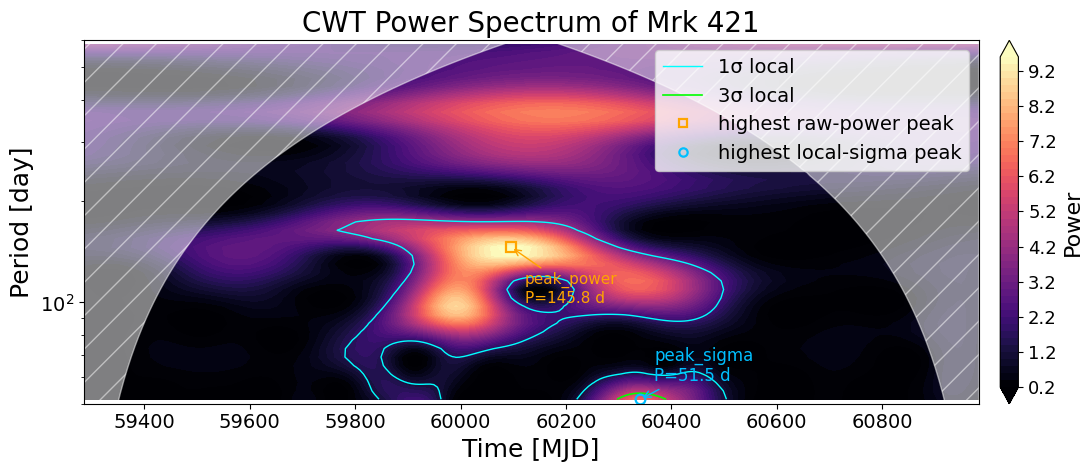

In [69]:
# 在现有 CWT power map 上叠加 1σ / 3σ / 5σ contour，并同时标出 peak_power / peak_sigma。
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(12, 5))

im = ax.contourf(
    T_local[maskP_local, :],
    P_local[maskP_local, :],
    power_obs_local[maskP_local, :],
    levels=50,
    cmap='magma',
    extend='both'
)

ax.fill_between(
    t_mjd,
    Pmax_local,
    coi_local,
    where=(coi_local <= Pmax_local),
    color='white',
    alpha=0.5,
    hatch='/'
)

contour_handles = []


def add_local_contour(threshold, color, lw, label):
    # contour 采用 local pre-trial 阈值，只在显示周期范围且 COI 外的区域作图。
    delta = np.where(plot_mask_local, power_obs_local - threshold[:, None], np.nan)
    if np.isfinite(delta).any() and np.nanmax(delta) > 0:
        ax.contour(T_local, P_local, delta, levels=[0], colors=color, linewidths=lw)
        contour_handles.append(Line2D([0], [0], color=color, lw=lw, label=label))


add_local_contour(thr1_local, 'cyan', 1.0, '1σ local')
add_local_contour(thr3_local, 'lime', 1.2, '3σ local')
add_local_contour(thr5_local, 'white', 1.2, '5σ local')

peak_handles = []

if same_peak_local:
    ax.plot(
        peak_time_sigma_local,
        peak_period_sigma_local,
        marker='o',
        markersize=7,
        markerfacecolor='none',
        markeredgecolor='deepskyblue',
        markeredgewidth=1.6,
    )
    ax.annotate(
        f'peak_power = peak_sigma\nP={peak_period_sigma_local:.1f} d',
        xy=(peak_time_sigma_local, peak_period_sigma_local),
        xycoords='data',
        xytext=(10, 10),
        textcoords='offset points',
        color='deepskyblue',
        fontsize=12,
        ha='left',
        va='bottom',
        arrowprops=dict(arrowstyle='->', color='deepskyblue', lw=1.0),
    )
    peak_handles.append(
        Line2D([0], [0], marker='o', color='deepskyblue', lw=0, markerfacecolor='none', markeredgewidth=1.6, label='peak_power = peak_sigma')
    )
else:
    ax.plot(
        peak_time_power_local,
        peak_period_power_local,
        marker='s',
        markersize=7,
        markerfacecolor='none',
        markeredgecolor='orange',
        markeredgewidth=1.6,
    )
    ax.annotate(
        f'peak_power\nP={peak_period_power_local:.1f} d',
        xy=(peak_time_power_local, peak_period_power_local),
        xycoords='data',
        xytext=(10, -18),
        textcoords='offset points',
        color='orange',
        fontsize=11,
        ha='left',
        va='top',
        arrowprops=dict(arrowstyle='->', color='orange', lw=1.0),
    )
    peak_handles.append(
        Line2D([0], [0], marker='s', color='orange', lw=0, markerfacecolor='none', markeredgewidth=1.6, label='highest raw-power peak')
    )

    ax.plot(
        peak_time_sigma_local,
        peak_period_sigma_local,
        marker='o',
        markersize=7,
        markerfacecolor='none',
        markeredgecolor='deepskyblue',
        markeredgewidth=1.6,
    )
    ax.annotate(
        f'peak_sigma\nP={peak_period_sigma_local:.1f} d',
        xy=(peak_time_sigma_local, peak_period_sigma_local),
        xycoords='data',
        xytext=(10, 10),
        textcoords='offset points',
        color='deepskyblue',
        fontsize=12,
        ha='left',
        va='bottom',
        arrowprops=dict(arrowstyle='->', color='deepskyblue', lw=1.0),
    )
    peak_handles.append(
        Line2D([0], [0], marker='o', color='deepskyblue', lw=0, markerfacecolor='none', markeredgewidth=1.6, label='highest local-sigma peak')
    )

ax.set_yscale('log')
ax.set_ylim(Pmin_local, Pmax_local)
ax.set_xlabel('Time [MJD]')
ax.set_ylabel('Period [day]')
ax.set_title('CWT Power Spectrum of Mrk 421')

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('Power', fontsize=16)
cbar.ax.tick_params(labelsize=13)

legend_handles = contour_handles + peak_handles
ax.legend(handles=legend_handles, loc='upper right', frameon=True)

plt.tight_layout()
plt.show()


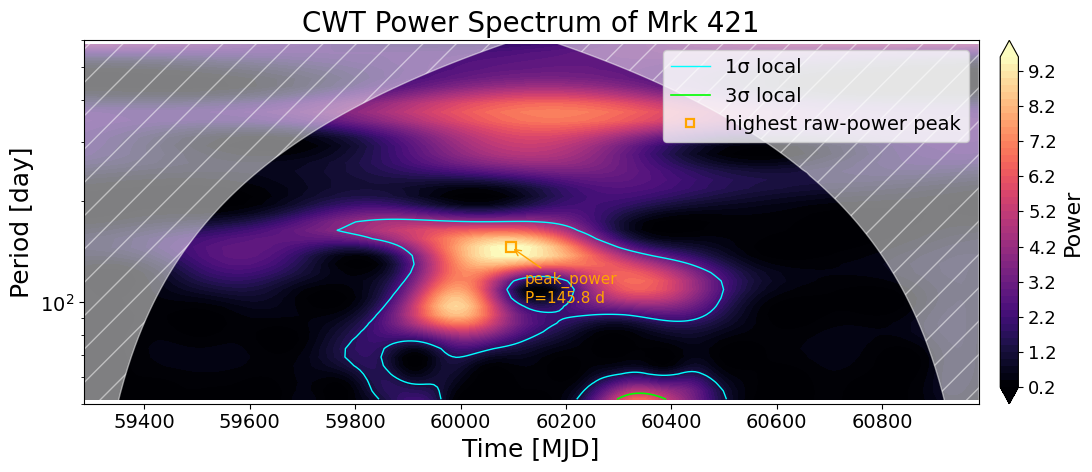

In [73]:
# 只展示 raw-power peak，便于与历史 notebook 中按最大 CWT power 选峰的结果直接比较。
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(12, 5))

im = ax.contourf(
    T_local[maskP_local, :],
    P_local[maskP_local, :],
    power_obs_local[maskP_local, :],
    levels=50,
    cmap='magma',
    extend='both'
)

ax.fill_between(
    t_mjd,
    Pmax_local,
    coi_local,
    where=(coi_local <= Pmax_local),
    color='white',
    alpha=0.5,
    hatch='/'
)

contour_handles = []


def add_local_contour(threshold, color, lw, label):
    delta = np.where(plot_mask_local, power_obs_local - threshold[:, None], np.nan)
    if np.isfinite(delta).any() and np.nanmax(delta) > 0:
        ax.contour(T_local, P_local, delta, levels=[0], colors=color, linewidths=lw)
        contour_handles.append(Line2D([0], [0], color=color, lw=lw, label=label))


add_local_contour(thr1_local, 'cyan', 1.0, '1σ local')
add_local_contour(thr3_local, 'lime', 1.2, '3σ local')
add_local_contour(thr5_local, 'white', 1.2, '5σ local')

ax.plot(
    peak_time_power_local,
    peak_period_power_local,
    marker='s',
    markersize=7,
    markerfacecolor='none',
    markeredgecolor='orange',
    markeredgewidth=1.6,
)

ax.annotate(
    f'peak_power\nP={peak_period_power_local:.1f} d',
    xy=(peak_time_power_local, peak_period_power_local),
    xycoords='data',
    xytext=(10, -18),
    textcoords='offset points',
    color='orange',
    fontsize=11,
    ha='left',
    va='top',
    arrowprops=dict(arrowstyle='->', color='orange', lw=1.0),
)

ax.set_yscale('log')
ax.set_ylim(Pmin_local, Pmax_local)
ax.set_xlabel('Time [MJD]')
ax.set_ylabel('Period [day]')
ax.set_title('CWT Power Spectrum of Mrk 421')

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('Power', fontsize=16)
cbar.ax.tick_params(labelsize=13)

legend_handles = contour_handles + [
    Line2D([0], [0], marker='s', color='orange', lw=0, markerfacecolor='none', markeredgewidth=1.6, label='highest raw-power peak')
]
ax.legend(handles=legend_handles, loc='upper right', frameon=True)

plt.tight_layout()
plt.show()


## 5. WWZ 分析

WCDA 周光变的不规则误差通过 on/off 计数近似传播到 `flux_excess_err`，再用于 WWZ 的清洗、时频图与 ridge 提取。

/tmp/ipykernel_2283821/3520185783.py:27: RuntimeWarning: invalid value encountered in divide
  alpha = n_bkg / n_off


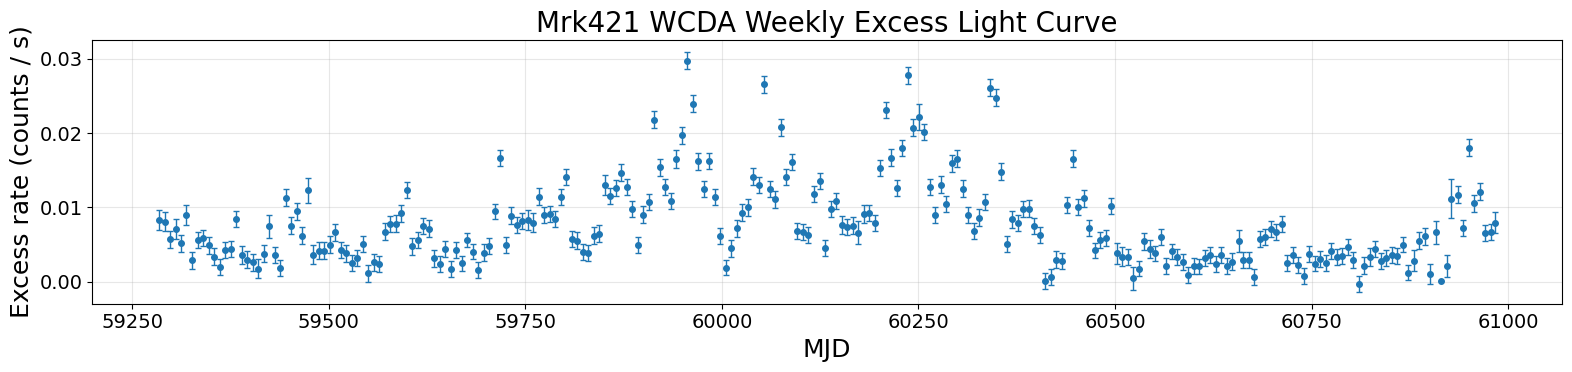

In [70]:
# plot excess light curve WITH statistical errors

import pandas as pd
import ast
import numpy as np
import matplotlib.pyplot as plt

path = str(WCDA_CSV)
df = pd.read_csv(path, comment="#")
df.columns = [c.strip() for c in df.columns]

# 读入 list 列
for col in ["n_on", "n_bkg", "n_off"]:
    df[col] = df[col].apply(ast.literal_eval).apply(np.array)

def excess_rate_and_err(row):
    n_on  = row["n_on"].astype(float)
    n_bkg = row["n_bkg"].astype(float)
    n_off = row["n_off"].astype(float)
    tobs  = float(row["tobs"])

    # excess
    excess = n_on - n_bkg
    excess_tot = excess.sum()

    # alpha per nhits bin
    alpha = n_bkg / n_off

    # statistical error per bin (Poisson on/off)
    sigma_bin = np.sqrt(n_on + (alpha**2) * n_off)

    # combine bins
    sigma_tot = np.sqrt(np.sum(sigma_bin**2))

    # rate and error
    rate = excess_tot / tobs
    rate_err = sigma_tot / tobs

    return pd.Series({
        "flux_excess": rate,
        "flux_excess_err": rate_err
    })

df = df.join(df.apply(excess_rate_and_err, axis=1))
df = df.sort_values("mjd")

# -------- plot --------
plt.figure(figsize=(16,4))
plt.errorbar(
    df["mjd"],
    df["flux_excess"],
    yerr=df["flux_excess_err"],
    fmt="o",
    ms=4,
    capsize=2,
    elinewidth=1
)
plt.xlabel("MJD")
plt.ylabel("Excess rate (counts / s)")
plt.title("Mrk421 WCDA Weekly Excess Light Curve")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


N=243, Tspan=1699.25 d, dt_med=7.00 d
WWZ settings:
  period range: [50.0, 500.0] d
  freq range:   [0.002, 0.02] 1/d
  freq_step:    2.94247e-05 1/d
  time_divisions: 250
  decay_constant: 0.0125
*** Starting Weighted Wavelet Z-transform ***

adjusted time_divisions to:  243
Pseudo sample frequency (median) is  0.143
largest tau window is  7.022
5.76 seconds has passed to complete Weighted Wavelet Z-transform 



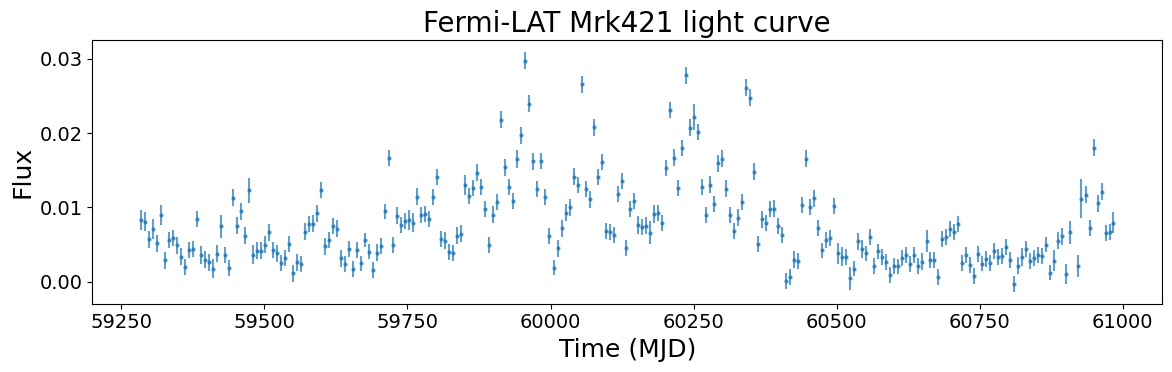

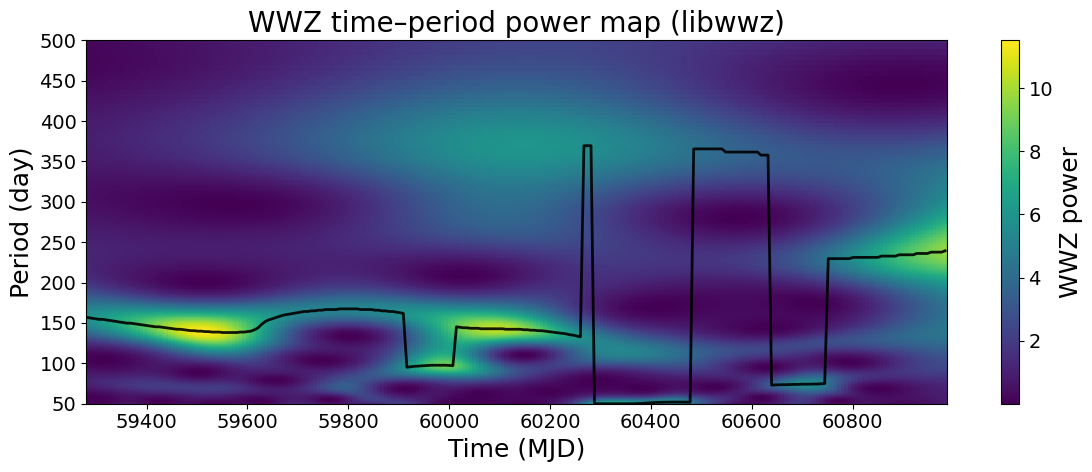

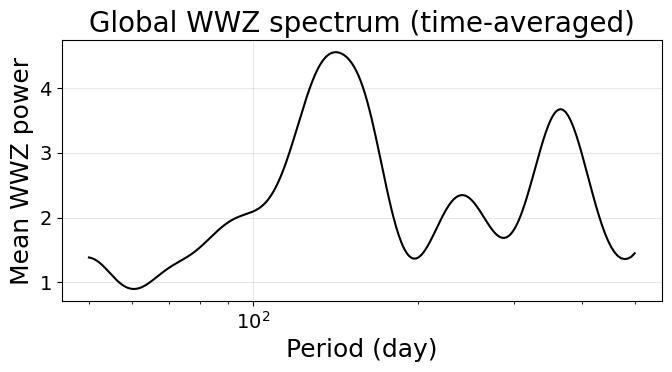

Top 10 ridge peaks (by WWZ power):
 1: tau=  59509.03  period=   139.873  power=       11.52
 2: tau=  59516.05  period=   139.300  power=       11.52
 3: tau=  59502.01  period=   139.873  power=       11.48
 4: tau=  59523.07  period=   139.300  power=       11.47
 5: tau=  59494.98  period=   140.451  power=       11.41
 6: tau=  59530.09  period=   138.731  power=       11.39
 7: tau=  59487.96  period=   140.451  power=       11.31
 8: tau=  59537.11  period=   138.731  power=       11.26
 9: tau=  59480.94  period=   141.034  power=       11.18
10: tau=  59544.14  period=   138.731  power=       11.09


In [71]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from libwwz import wwt

# ============================================================
# 0) 读取 LHAASO WCDA Fermi Mrk421 光子计数
# ============================================================
import numpy as np
t_mjd = df["mjd"] 
flux = df["flux_excess"]
flux_err = df["flux_excess_err"]
# 去掉 NaN 或 TS 很低的点（如果有的话）
mask = np.isfinite(flux)
t_mjd = t_mjd[mask]
flux  = flux[mask].astype(float)
flux_err = flux_err[mask].astype(float)

# ============================================================
# 1) 清洗 + 排序 + 合并重复时间（推荐，避免 WWZ/GP 数值问题）
# ============================================================
def clean_and_merge(t, y, yerr):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    yerr = np.asarray(yerr, dtype=float)

    m = np.isfinite(t) & np.isfinite(y) & np.isfinite(yerr) & (yerr > 0)
    t, y, yerr = t[m], y[m], yerr[m]

    s = np.argsort(t)
    t, y, yerr = t[s], y[s], yerr[s]

    uniq_t, idx_start = np.unique(t, return_index=True)
    if len(uniq_t) == len(t):
        return t, y, yerr

    y_new = np.empty_like(uniq_t, dtype=float)
    e_new = np.empty_like(uniq_t, dtype=float)

    for k in range(len(uniq_t)):
        i0 = idx_start[k]
        i1 = idx_start[k+1] if (k+1 < len(uniq_t)) else len(t)
        w = 1.0 / (yerr[i0:i1] ** 2)
        y_new[k] = np.sum(w * y[i0:i1]) / np.sum(w)
        e_new[k] = np.sqrt(1.0 / np.sum(w))

    return uniq_t, y_new, e_new

t, y, yerr = clean_and_merge(t_mjd, flux, flux_err)

Tspan = t.max() - t.min()
dt_med = np.median(np.diff(t))
print(f"N={len(t)}, Tspan={Tspan:.2f} d, dt_med={dt_med:.2f} d")

# ============================================================
# 2) 设定 WWZ 参数（按你的科学问题改这里）
# ============================================================
# 你说你关心 ~300 d 周期，这里给个覆盖范围，比如 150–1000 d
period_min = 50.0
period_max = 500.0
freq_low  = 1.0 / period_max
freq_high = 1.0 / period_min

# 频率步长：经验做法：和总时长成反比
# 步长越小越细，但更慢。可以先粗后细。
freq_step = 0.05 / Tspan

# time_divisions：时间网格数（越大时间分辨率越高，但越慢）
time_divisions = 250

# 衰减常数 c：越大时间定位越强，频率分辨率越差
# 你之前用 0.0125 没问题；周期更长时也可更小一点
decay_constant = 0.0125

print("WWZ settings:")
print(f"  period range: [{period_min}, {period_max}] d")
print(f"  freq range:   [{freq_low:.6g}, {freq_high:.6g}] 1/d")
print(f"  freq_step:    {freq_step:.6g} 1/d")
print(f"  time_divisions: {time_divisions}")
print(f"  decay_constant: {decay_constant}")

# ============================================================
# 3) 计算 WWZ（libwwz）
# ============================================================
out = wwt(
    timestamps=t.astype(float),
    magnitudes=y.astype(float),
    time_divisions=time_divisions,
    freq_params=[freq_low, freq_high, freq_step, True],
    decay_constant=decay_constant,
    method="linear",
    parallel=True
)

tau_mat, freq_mat, wwz_mat, amp_mat, coef_mat, neff_mat = out
period_mat = 1.0 / freq_mat

# ============================================================
# 4) Ridge：每个 tau 上 WWZ 最大对应的 period
# ============================================================
ridge_idx = np.argmax(wwz_mat, axis=1)
ridge_tau = tau_mat[:, 0]
ridge_period = period_mat[np.arange(len(ridge_idx)), ridge_idx]
ridge_power  = wwz_mat[np.arange(len(ridge_idx)), ridge_idx]

# ============================================================
# 5) 作图：光变 + WWZ 时频图 + ridge
# ============================================================
plt.figure(figsize=(12, 4))
plt.errorbar(t, y, yerr=yerr, fmt=".", ms=4, alpha=0.7)
plt.xlabel("Time (MJD)")
plt.ylabel("Flux")
plt.title("Fermi-LAT Mrk421 light curve")
plt.tight_layout()
plt.show()

# 为了让 period 轴递增，我们对列按 period 排序
sort_idx = np.argsort(period_mat[0, :])    # period 递增
tau_plot = tau_mat[:, 0]
period_plot = period_mat[:, sort_idx]
wwz_plot = wwz_mat[:, sort_idx]
p_axis = period_plot[0, :]

plt.figure(figsize=(12, 5))
plt.pcolormesh(tau_plot, p_axis, wwz_plot.T, shading="auto")
plt.xlabel("Time (MJD)")
plt.ylabel("Period (day)")
plt.title("WWZ time–period power map (libwwz)")
cbar = plt.colorbar()
cbar.set_label("WWZ power")

plt.plot(ridge_tau, ridge_period, "k-", lw=2, alpha=0.9)
plt.ylim(period_min, period_max)
plt.tight_layout()
plt.show()

# ============================================================
# 6) （很有用）全局 WWZ spectrum：对时间求平均，看主周期候选
# ============================================================
gwwz = np.nanmean(wwz_mat, axis=0)  # (nfreq,)
period_axis = 1.0 / freq_mat[0, :]

# period 递增排序
p_sort = np.argsort(period_axis)
plt.figure(figsize=(7,4))
plt.plot(period_axis[p_sort], gwwz[p_sort], "k-")
plt.xscale("log")
plt.xlabel("Period (day)")
plt.ylabel("Mean WWZ power")
plt.title("Global WWZ spectrum (time-averaged)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 7) 打印 ridge 的最强若干点（粗看哪些时段最强）
# ============================================================
topk = 10
idx_sorted = np.argsort(ridge_power)[::-1]
print(f"Top {topk} ridge peaks (by WWZ power):")
for k in range(topk):
    i = idx_sorted[k]
    print(f"{k+1:2d}: tau={ridge_tau[i]:10.2f}  period={ridge_period[i]:10.3f}  power={ridge_power[i]:12.4g}")


## 6. 预计算 HDF5 模拟样本检查

上面的显著性部分已经直接使用了 `wcda_weekly_sims_full.h5`。这里保留更细的抽样检查单元，用于单独验证 HDF5 中保存的时间轴、样本分布与 PSD 是否稳定。如果需要重新生成该文件，请使用 `mkn421_lhaaso/simulations/generate_wcda_weekly_sims.py`。

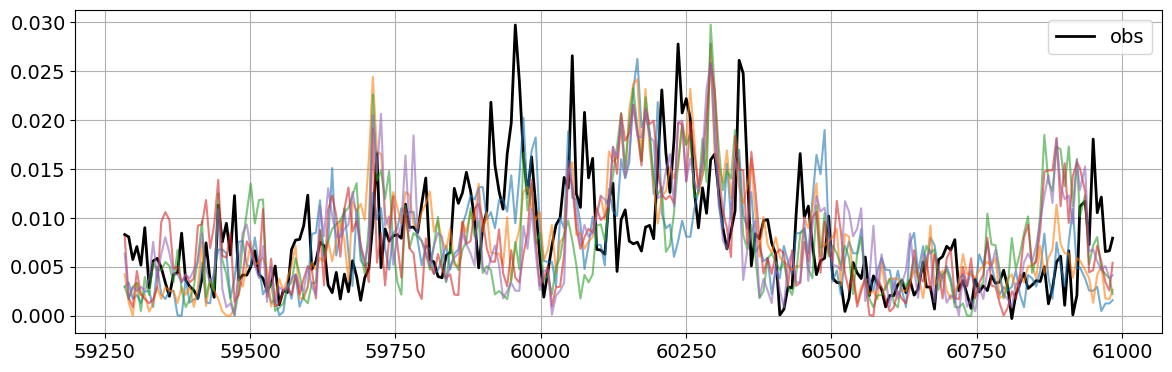

In [72]:
# 加载 simulations HDF5，快速查看观测曲线与若干条已保存模拟曲线。
import h5py
import numpy as np
import matplotlib.pyplot as plt

with h5py.File(SIM_H5, 'r') as f:
    t = f['t_mjd_clean'][:]
    flux_obs = f['flux_obs_clean'][:]
    flux_sims_preview = np.asarray(f['flux_sims'][:5], dtype=float)

plt.figure(figsize=(12, 4))
plt.plot(t, flux_obs, 'k-', lw=2, label='obs')
for flux_sim in flux_sims_preview:
    plt.plot(t, flux_sim, alpha=0.6)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. 归档说明

- 2D local significance、joblib 并行版本的大规模模拟、以及两套 WWZ 显著性原型没有删除，而是保留在归档 notebook 中。
- 当前整理版强调“主流程可读性”，不把尚未定稿的显著性试验直接混入主分析叙事。